# Hands-On Network Visualization Exercises

Reproduce and interpret all seven mandatory exercises.

**Student:** S. M. Monowar Kayser (253-25-019)  
**Course:** Data Visualization (CSE628), Summer 2026

All paths are project-relative and all reported values are calculated from the stored data or `outputs/analysis_summary.json`.

In [1]:
from pathlib import Path
import json
import sys
from IPython.display import Image, display
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
SUMMARY = json.loads((ROOT / 'outputs' / 'analysis_summary.json').read_text(encoding='utf-8'))
print('Project root resolved successfully.')
print('Canonical summary: outputs/analysis_summary.json')

Project root resolved successfully.
Canonical summary: outputs/analysis_summary.json


## Exercise 1 - Weighted adjacency representations

**Objective.** Recreate the supplied `G_transport` graph, print its adjacency list, calculate the weighted matrix, and test symmetry.

In [2]:
import numpy as np
from src.graph_generators import build_transport_graph
from src.network_analysis import transport_representations
G_transport = build_transport_graph()
transport_matrix, transport_result = transport_representations(G_transport)
print('Adjacency list:')
for node, neighbours in transport_result['adjacency_list'].items():
    print(f'{node}: {neighbours}')
display(transport_matrix)
print('Symmetric:', np.allclose(transport_matrix, transport_matrix.T))

Adjacency list:
Dhaka: ['Chattogram', 'Sylhet', 'Khulna', 'Rajshahi', 'Barishal', 'Rangpur']
Chattogram: ['Dhaka', 'Sylhet']
Sylhet: ['Dhaka', 'Chattogram']
Khulna: ['Dhaka', 'Barishal']
Rajshahi: ['Dhaka', 'Rangpur']
Barishal: ['Dhaka', 'Khulna']
Rangpur: ['Dhaka', 'Rajshahi']


,Dhaka,Chattogram,Sylhet,Khulna,Rajshahi,Barishal,Rangpur
city,,,,,,,
Dhaka,0.0,264.0,247.0,209.0,256.0,170.0,300.0
Chattogram,264.0,0.0,350.0,0.0,0.0,0.0,0.0
Sylhet,247.0,350.0,0.0,0.0,0.0,0.0,0.0
Khulna,209.0,0.0,0.0,0.0,0.0,130.0,0.0
Rajshahi,256.0,0.0,0.0,0.0,0.0,0.0,130.0
Barishal,170.0,0.0,0.0,130.0,0.0,0.0,0.0
Rangpur,300.0,0.0,0.0,0.0,130.0,0.0,0.0


Symmetric: True


**Interpretation.** The matrix is symmetric because every route is undirected and has one shared distance. A directed or direction-dependent transport graph could produce an asymmetric matrix.

**Limitation.** The seven-city graph is a teaching example rather than a complete or geographically validated route network.

## Exercise 2 - Six-layout comparison

**Objective.** Compare spring, circular, shell, spectral, Kamada-Kawai, and random placement while holding topology and styling fixed.

{'nodes': 15,
 'edges': 15,
 'density': 0.14285714285714285,
 'average_degree': 2.0,
 'average_clustering': 0.0,
 'connected': True,
 'connected_components': 1,
 'average_shortest_path': 3.619047619047619,
 'average_shortest_path_scope': 'whole graph',
 'maximum_degree': 4,
 'degree_standard_deviation': 0.9660917830792959}

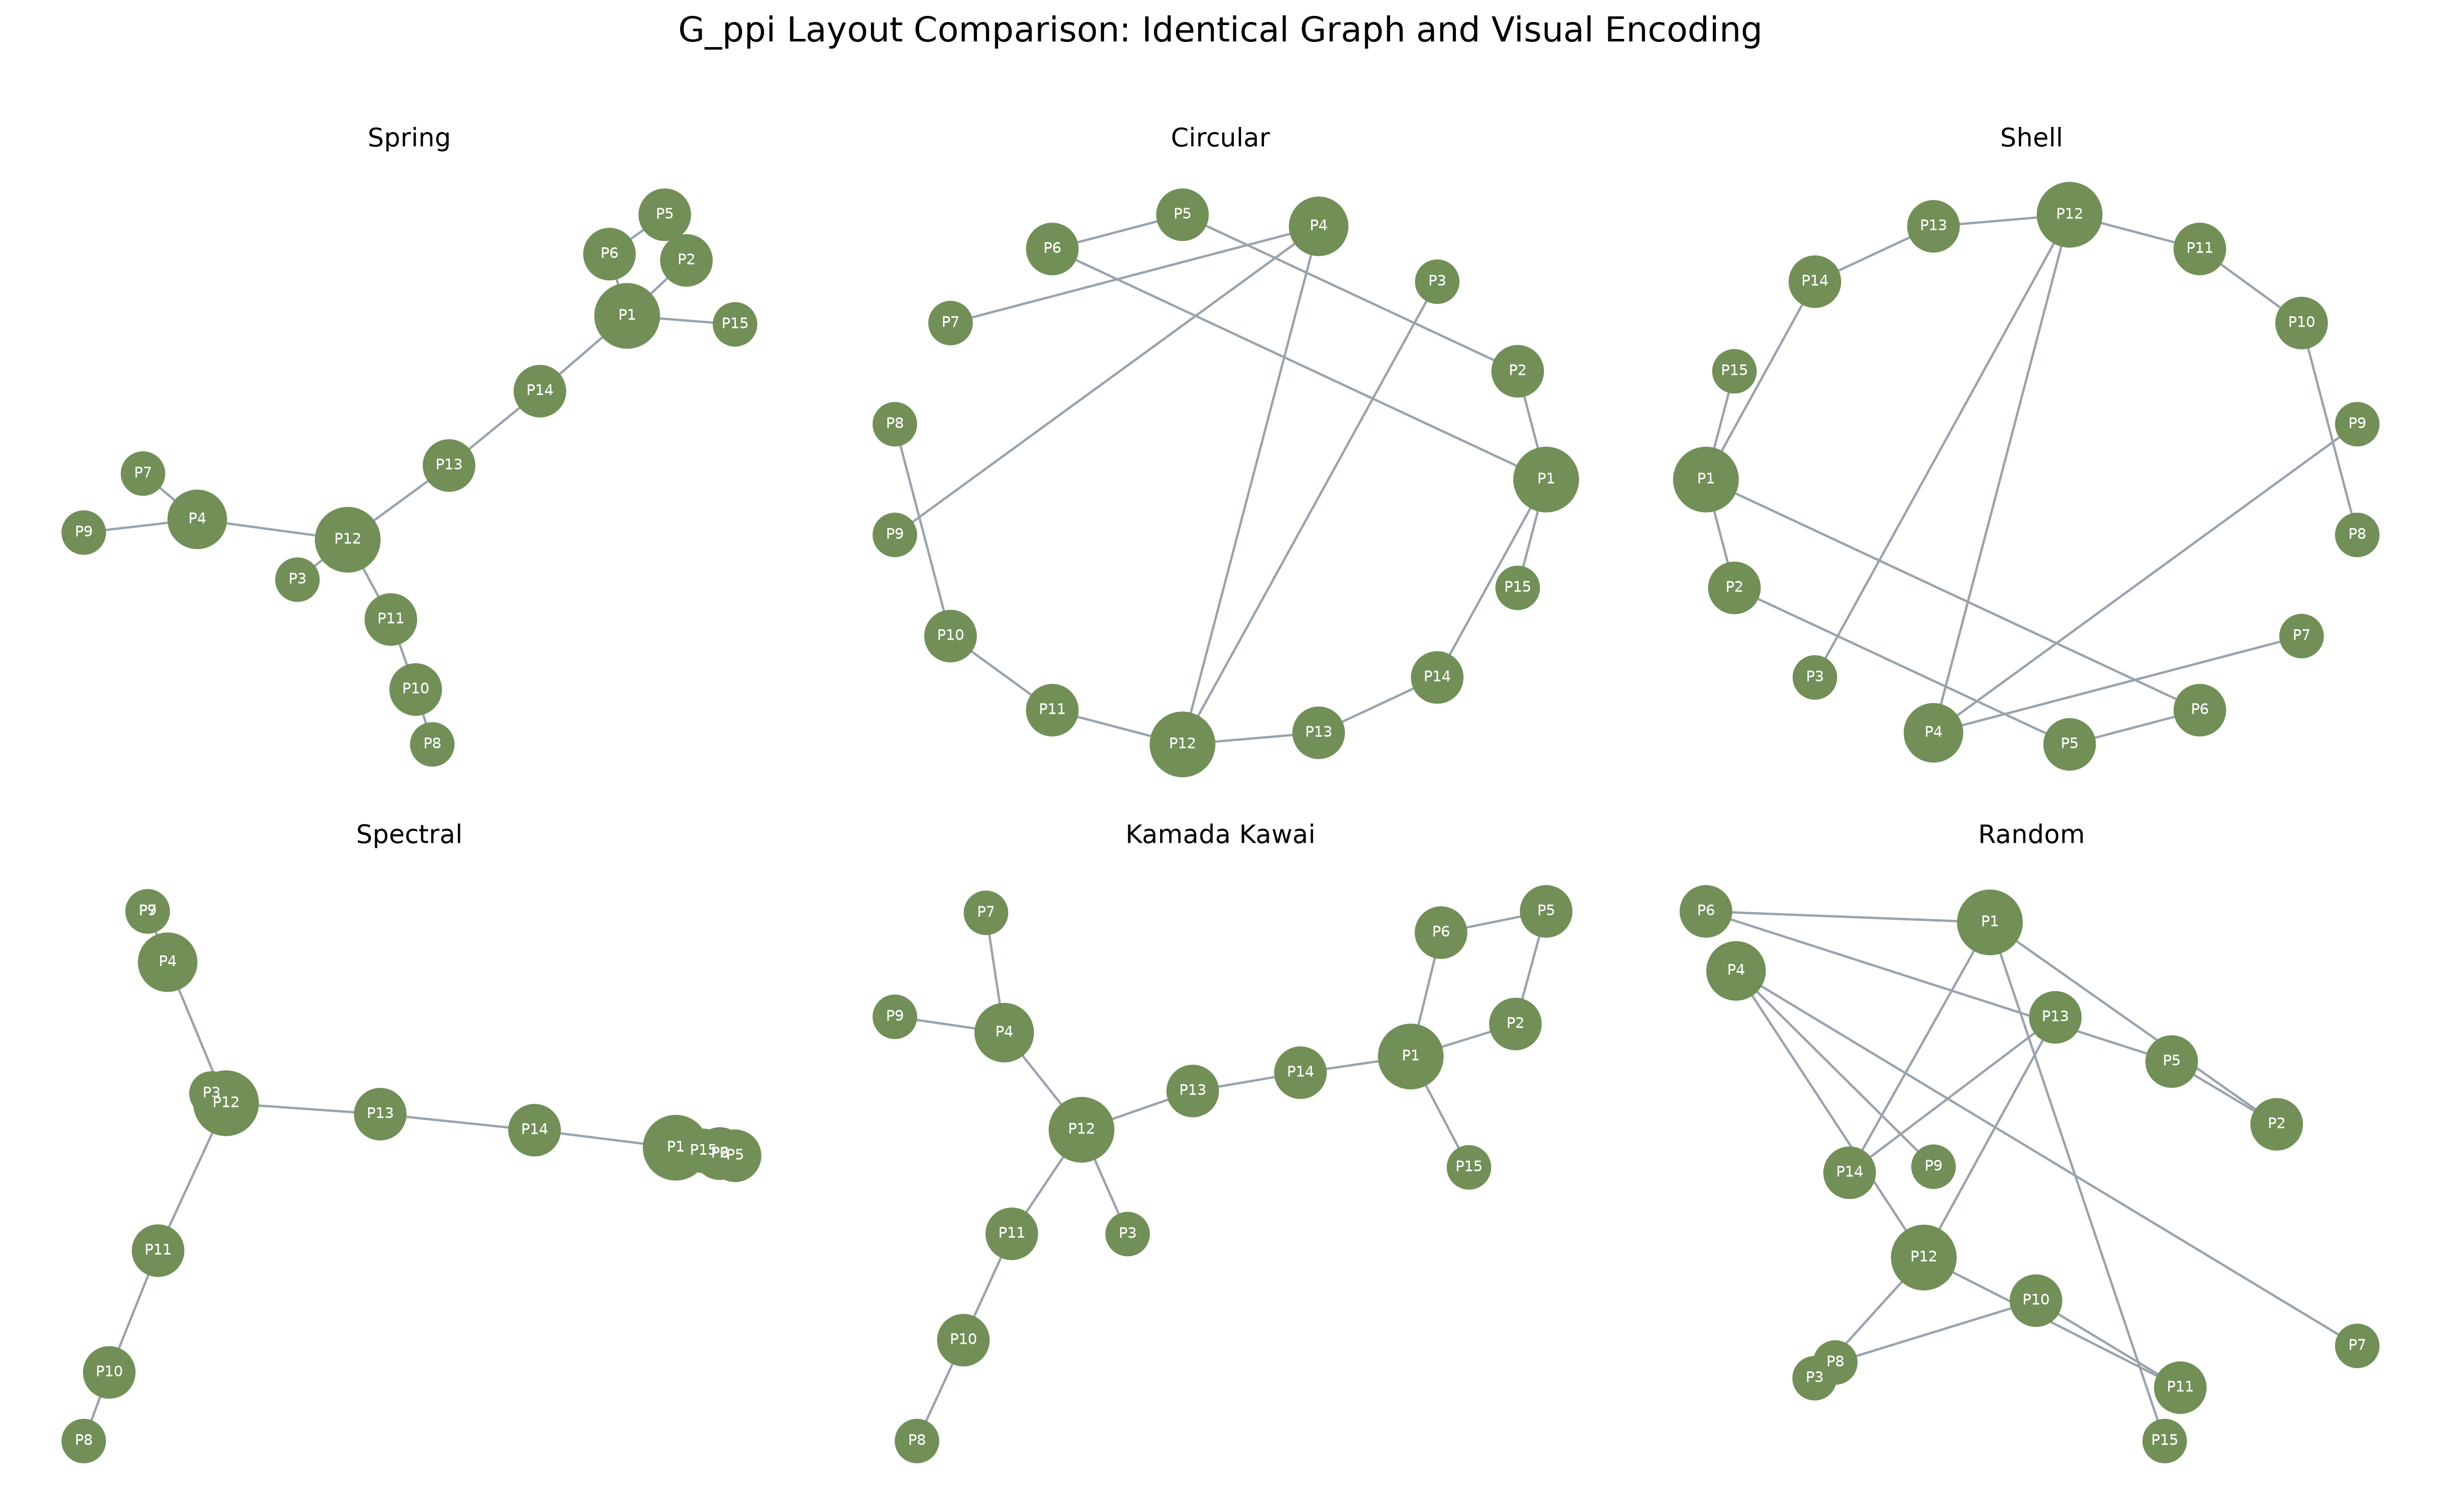

In [3]:
from IPython.display import Image, display
from src.graph_generators import build_ppi_graph, graph_metrics
G_ppi = build_ppi_graph()
display(graph_metrics(G_ppi))
display(Image(filename=str(ROOT / 'visualizations' / 'static' / 'g_ppi_layout_comparison.png')))

**Interpretation.** Kamada-Kawai gives the clearest distance-oriented view of ring locality and rewired shortcuts for this realization. The calculated clustering coefficient is 0.000, so no layout can establish triangle-based clusters that are absent from the graph.

**Limitation.** Layout preference depends on topology, scale, labels, and the reader's task; it is not a universal ranking.

## Exercise 3 - Student-course bipartite network

**Objective.** Build a two-mode graph from stored synthetic CSV tables and identify course popularity and student course load.

Bipartite: True


,node_id,label,node_type,degree,major_or_department
12,C01,Data Visualization,course,12,Computer Science
14,C03,Machine Learning,course,7,Artificial Intelligence
13,C02,Social Network Analysis,course,6,Computer Science
15,C04,Database Systems,course,5,Computer Science
16,C05,Human-Computer Interaction,course,5,Multimedia
17,C06,Research Methodology,course,5,General Studies
8,S09,Imran Kabir,student,5,Computer Science
0,S01,Ayesha Rahman,student,4,Computer Science
4,S05,Farzana Islam,student,4,Data Science
11,S12,Raisa Noor,student,4,Data Science


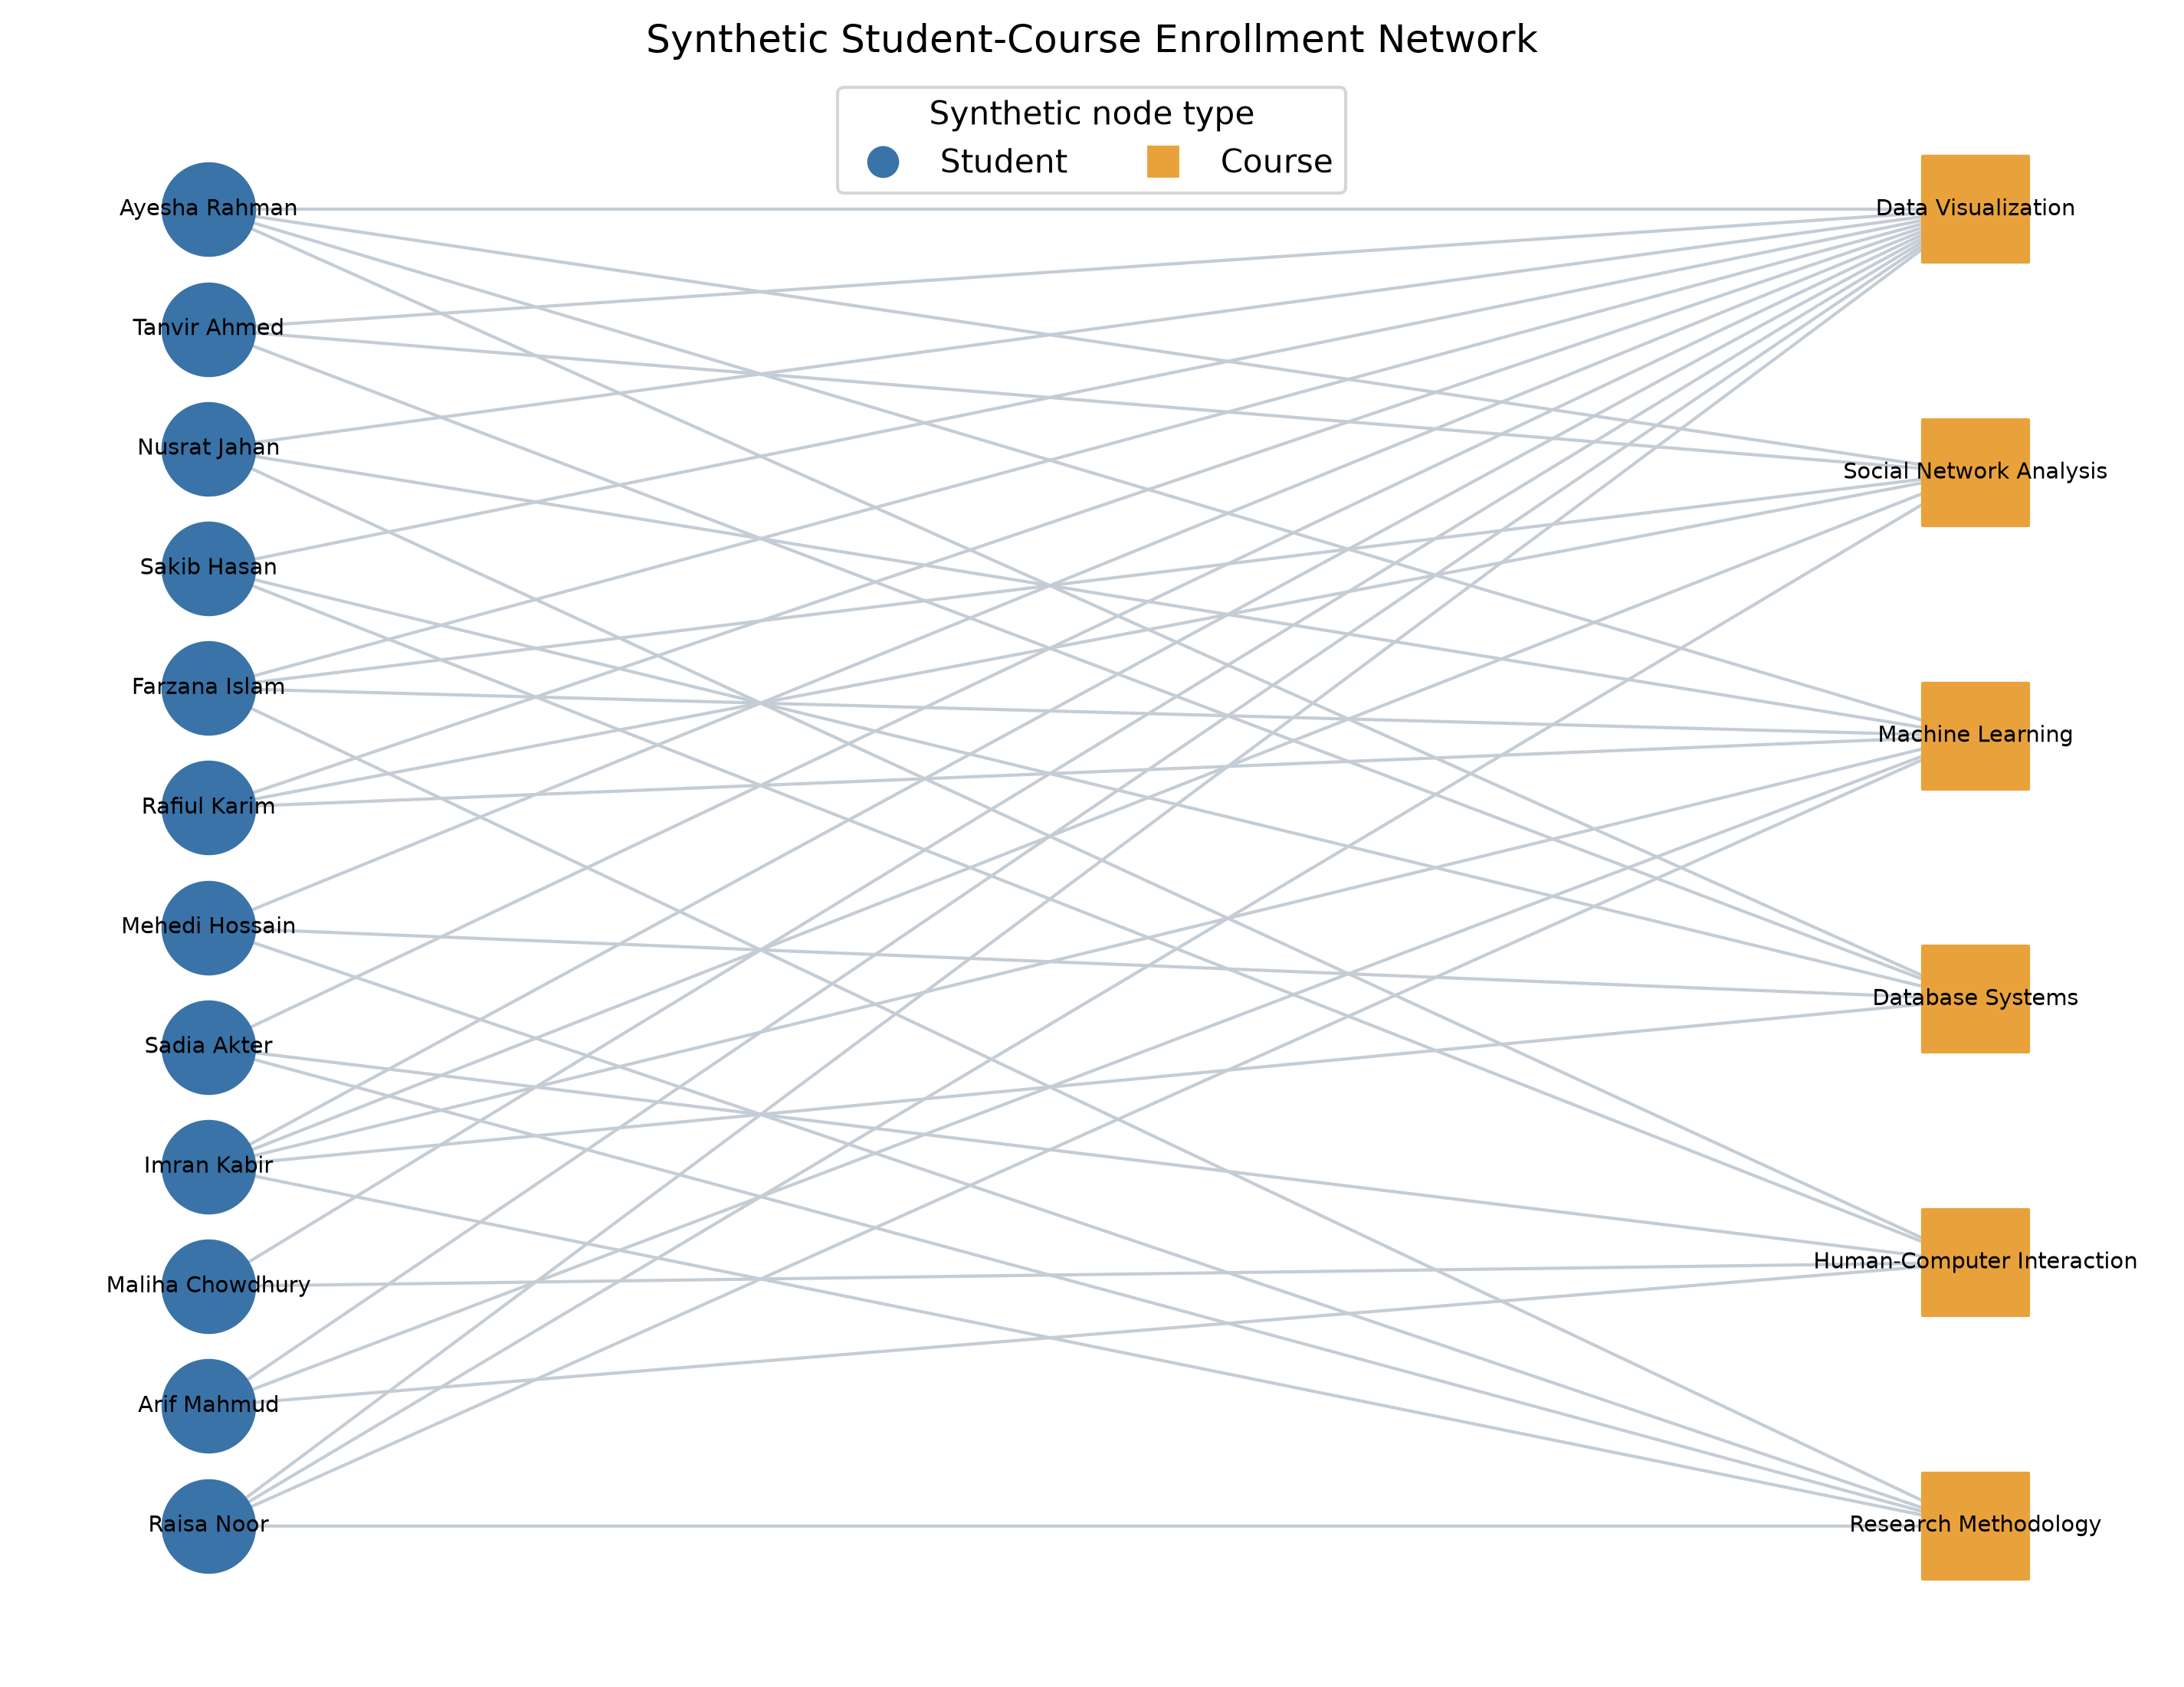

In [4]:
import networkx as nx
from src.graph_generators import load_student_course_graph
from src.network_analysis import student_course_findings
student_graph, students, courses, enrollments = load_student_course_graph()
degree_table, student_result = student_course_findings()
print('Bipartite:', nx.algorithms.bipartite.is_bipartite(student_graph))
display(degree_table)
display(Image(filename=str(ROOT / 'visualizations' / 'static' / 'student_course_bipartite_graph.png')))

**Interpretation.** Degree represents course load for student nodes and synthetic popularity for course nodes. These meanings must not be conflated.

**Limitation.** Names, majors, courses, and enrollments are illustrative and do not describe actual Daffodil International University records.

## Exercise 4 - Weighted Barabasi-Albert graph

**Objective.** Assign reproducible integer edge weights from 1 to 10 and encode them through line width without changing topology.

,source,target,weight
0,0,1,2
1,0,2,1
2,0,3,5
3,0,5,4
4,0,7,4
5,0,9,3
6,0,10,2
7,0,11,9
8,0,13,2
9,0,14,10


count    196.000000
mean       5.387755
std        2.859559
min        1.000000
25%        3.000000
50%        5.000000
75%        8.000000
max       10.000000
Name: weight, dtype: float64

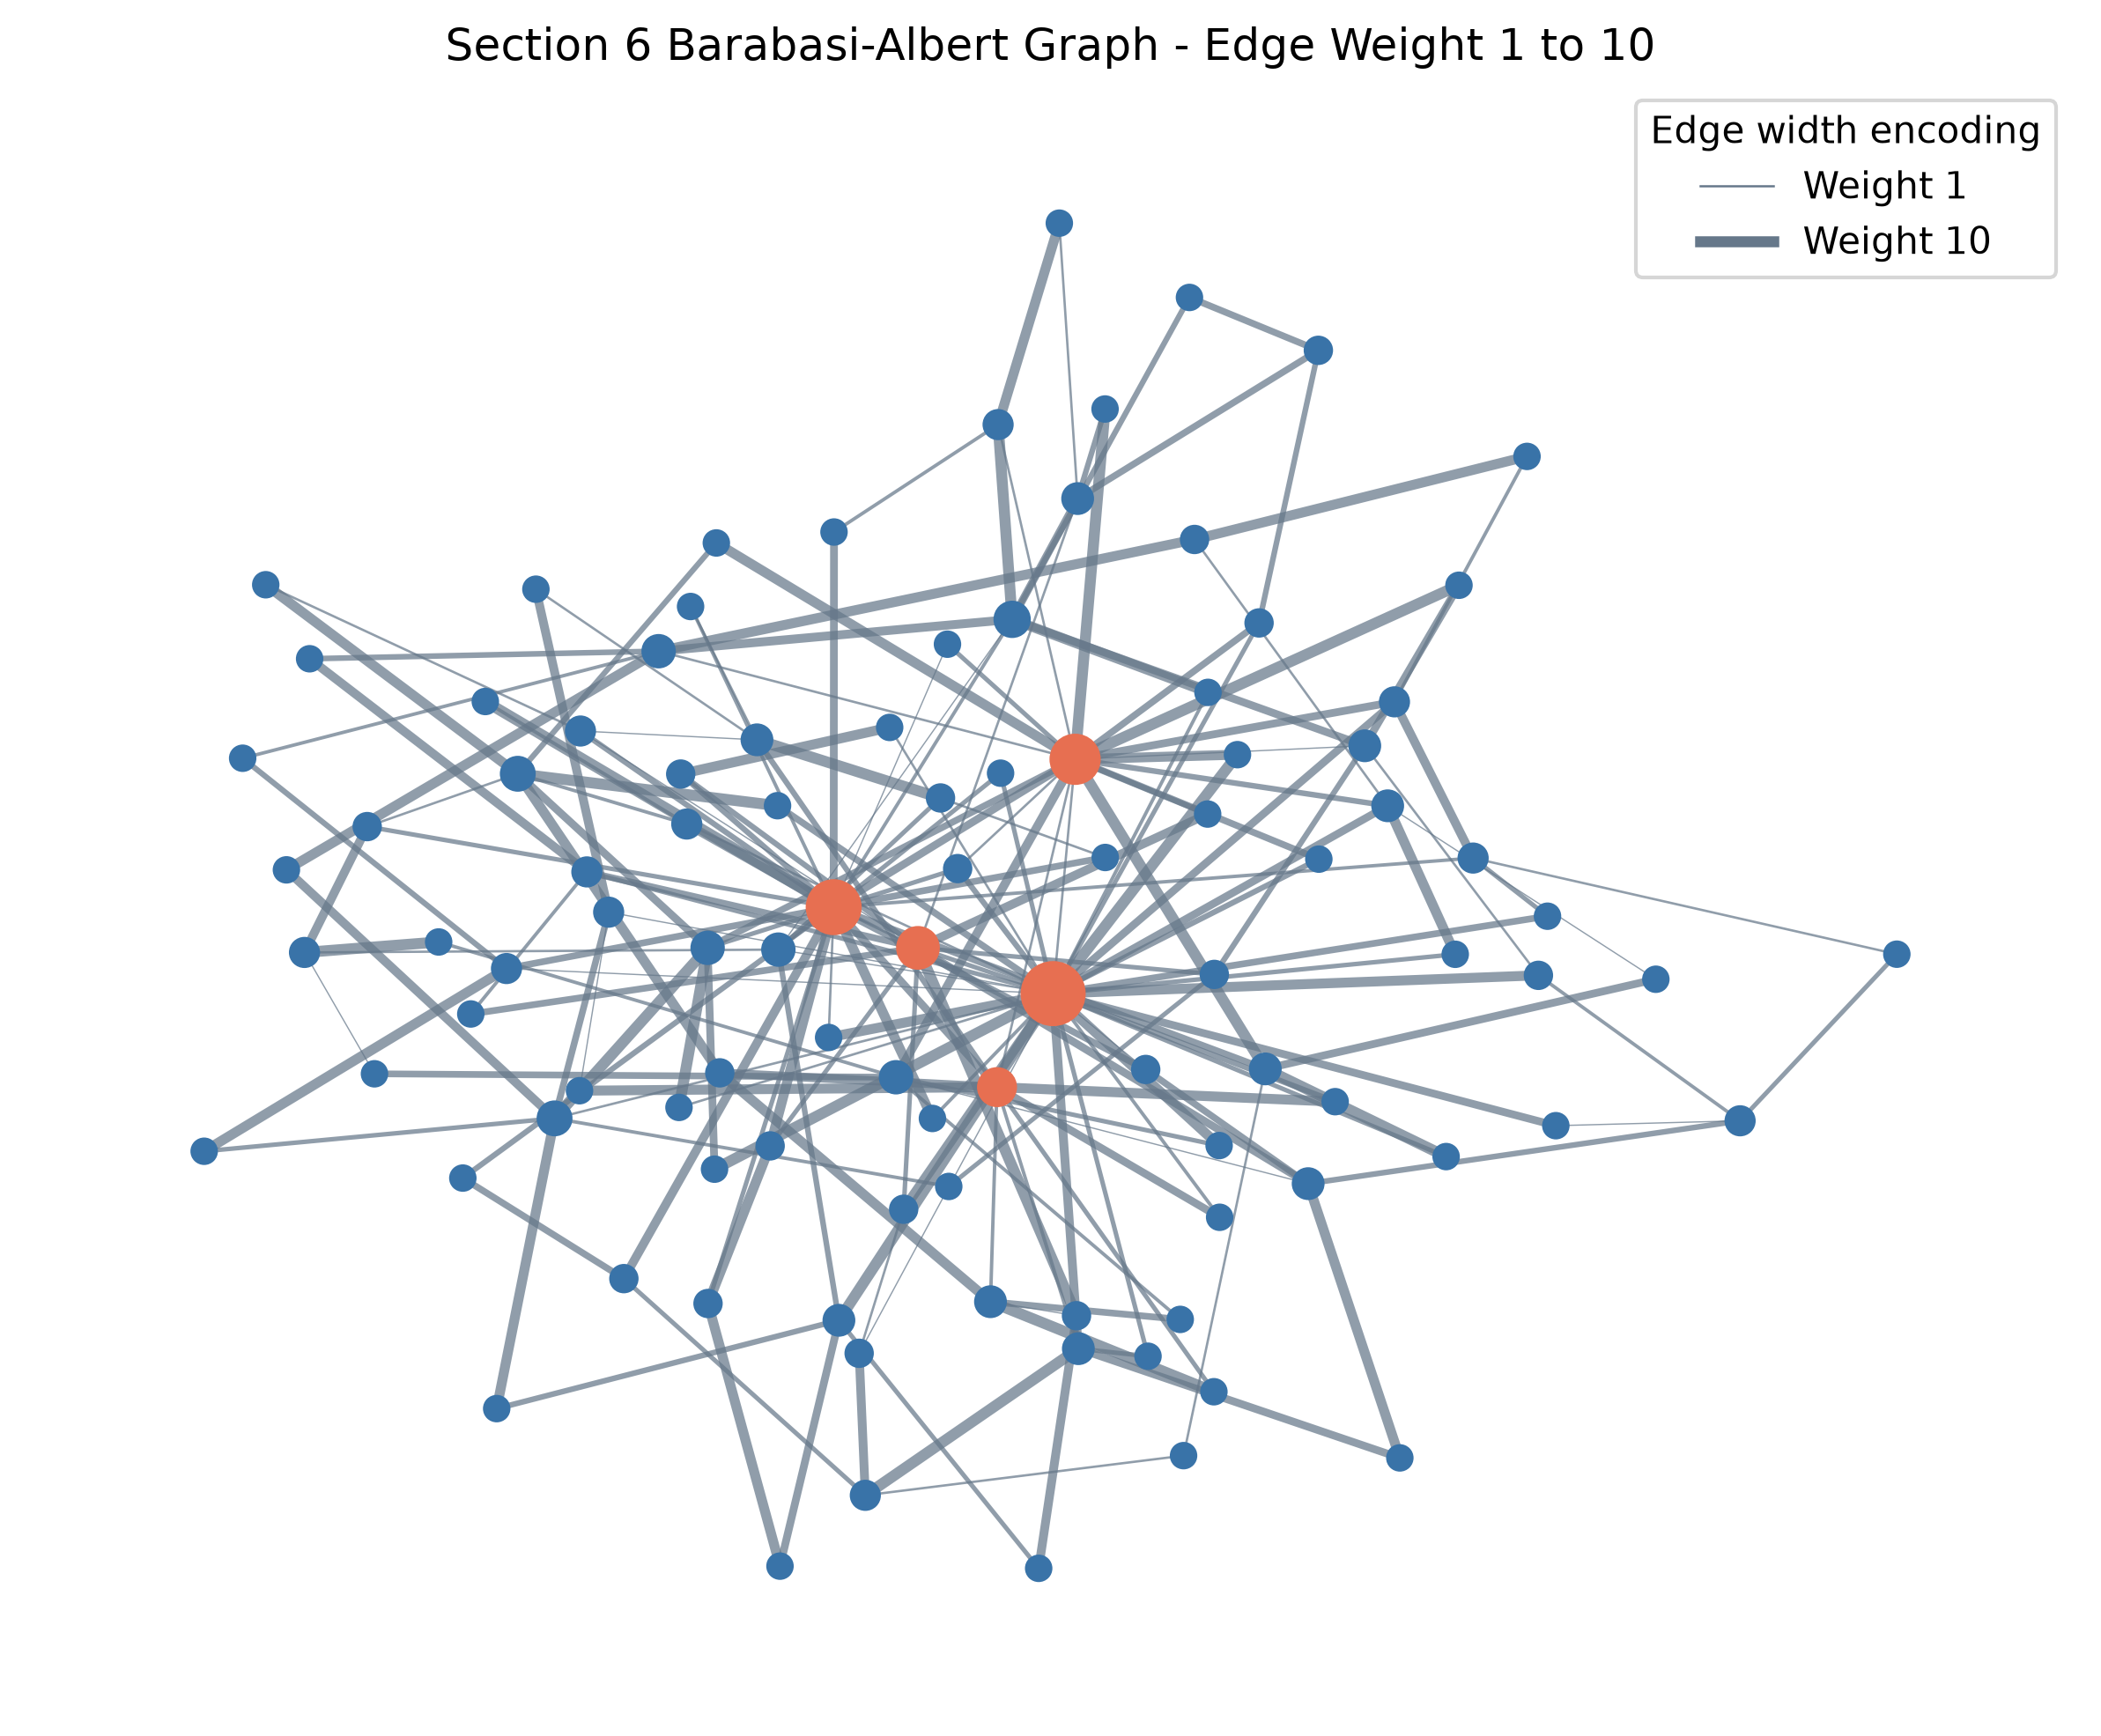

In [5]:
import pandas as pd
weights = pd.read_csv(ROOT / 'outputs' / 'tables' / 'barabasi_albert_edge_weights.csv')
display(weights.head(10))
display(weights['weight'].describe())
display(Image(filename=str(ROOT / 'visualizations' / 'static' / 'barabasi_albert_weighted.png')))

**Interpretation.** Width changes the salience of selected ties, but random edge weights do not redefine which nodes are degree hubs. A weighted centrality measure would require a justified strength or distance meaning.

**Limitation.** The weights demonstrate visual encoding only.

## Exercise 5 - Generative-model statistics

**Objective.** Compare the exact seeded Erdos-Renyi, Watts-Strogatz, and Barabasi-Albert realizations using consistent structural metrics.

,Model,Nodes,Edges,Density,Average Degree,Average Clustering,Connected,Connected Components,Average Shortest Path,Path Length Scope,Maximum Degree,Degree Standard Deviation,Social-Network Similarity Notes
0,"Erdos-Renyi G(n,p)",30,33,0.075862,2.200000,0.072222,False,3,3.828042,largest connected component,4,1.166190,Homogeneous random mixing; limited clustering ...
1,Watts-Strogatz small-world,30,60,0.137931,4.000000,0.345556,True,1,2.983908,whole graph,5,0.632456,"High local clustering and short paths, but com..."
2,Barabasi-Albert scale-free,30,56,0.128736,3.733333,0.300196,True,1,2.181609,whole graph,18,3.520732,"Strong hubs and heterogeneous degrees, but wea..."


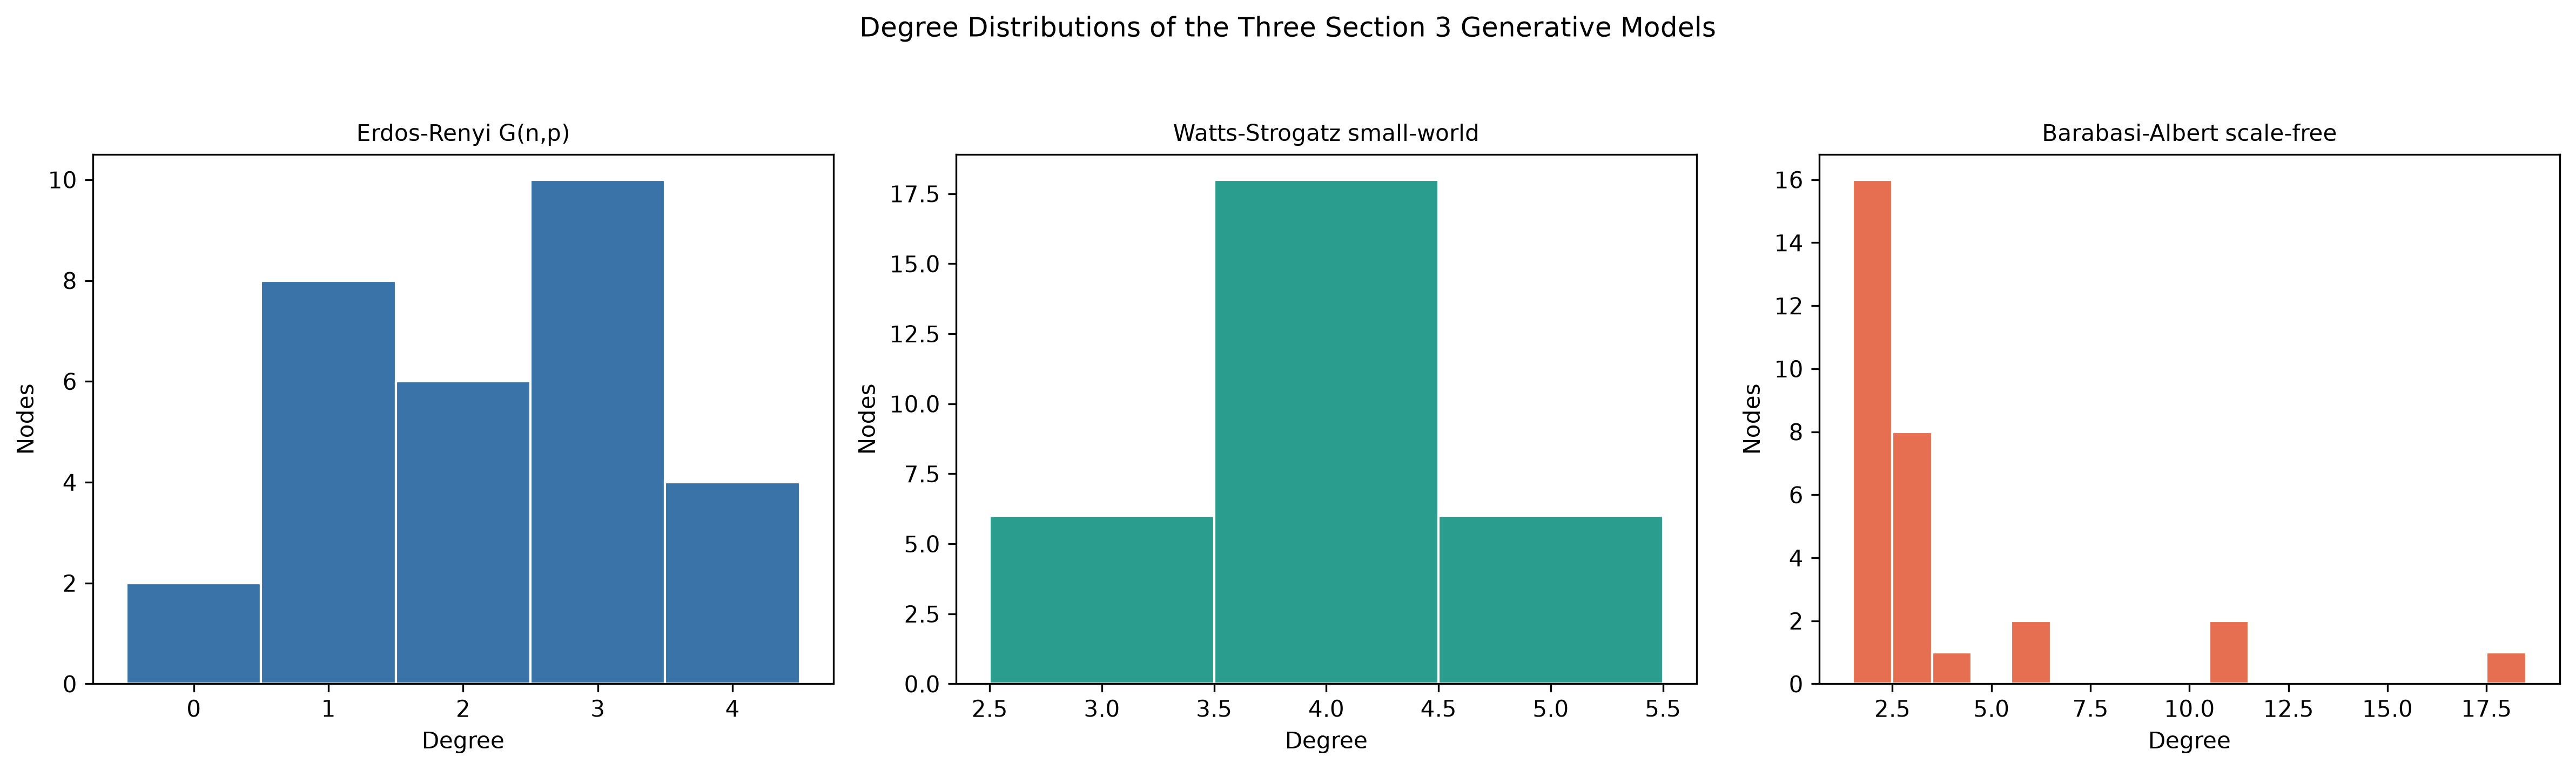

In [6]:
from src.graph_generators import build_generative_models
from src.network_analysis import compare_generative_models
model_table, distributions = compare_generative_models(build_generative_models())
display(model_table)
display(Image(filename=str(ROOT / 'visualizations' / 'static' / 'generative_models_degree_distribution.png')))

**Interpretation.** Watts-Strogatz better represents clustering and short paths, whereas Barabasi-Albert better represents hubs and heterogeneous degree. Neither is universally closest to every social network.

**Limitation.** One small realization per model cannot characterize the full sampling distribution of the metrics.

## Exercise 6 - Interactive node-color dashboard

**Objective.** Preserve node positions while toggling color between categorical interest group and continuous in-degree.

In [7]:
from IPython.display import HTML, display
dashboard_path = ROOT / 'visualizations' / 'interactive' / 'network_color_toggle_dashboard.html'
dashboard_html = dashboard_path.read_text(encoding='utf-8')
print('Standalone size:', f'{dashboard_path.stat().st_size / 1024:.1f} KiB')
print('Dropdown labels present:', all(label in dashboard_html for label in ['Color by Interest Group', 'Color by In-Degree']))
display(HTML('<a href="../visualizations/interactive/network_color_toggle_dashboard.html" target="_blank">Open standalone dashboard</a>'))

Standalone size: 20.7 KiB
Dropdown labels present: True


**Interpretation.** Fixed coordinates isolate the effect of color: the categorical view supports group-mixing inspection and the continuous view emphasizes incoming-tie popularity.

**Limitation.** Plotly line traces do not show arrowheads; direction is communicated through in-degree and out-degree values.

## Exercise 7 - Applied AI and Multimedia knowledge graph

**Objective.** Build a typed, weighted graph from CSV files and calculate degree, inverse-strength betweenness, closeness, and PageRank.

,node_id,label,node_type,degree,degree_centrality,betweenness_centrality,closeness_centrality,pagerank
3,RS,Recommendation Systems,Research area,5,0.357143,0.538462,0.560000,0.129719
0,AI,Artificial Intelligence,Research area,3,0.214286,0.250916,0.466667,0.078971
5,DL,Deep Learning,Method,4,0.285714,0.192308,0.466667,0.101088
1,CV,Computer Vision,Research area,3,0.214286,0.166667,0.437500,0.079492
6,GNN,Graph Neural Networks,Method,3,0.214286,0.161172,0.500000,0.063005
11,EduTech,Educational Technology,Application,3,0.214286,0.153846,0.437500,0.078465
7,CF,Collaborative Filtering,Method,2,0.142857,0.109890,0.424242,0.054267
14,Personalize,Personalized Content,Outcome,2,0.142857,0.054945,0.388889,0.052558
2,NLP,Natural Language Processing,Research area,3,0.214286,0.045788,0.437500,0.071598
12,SmartMedia,Smart Multimedia,Application,3,0.214286,0.043956,0.378378,0.065008


Top bridge: Recommendation Systems 0.5384615384615385


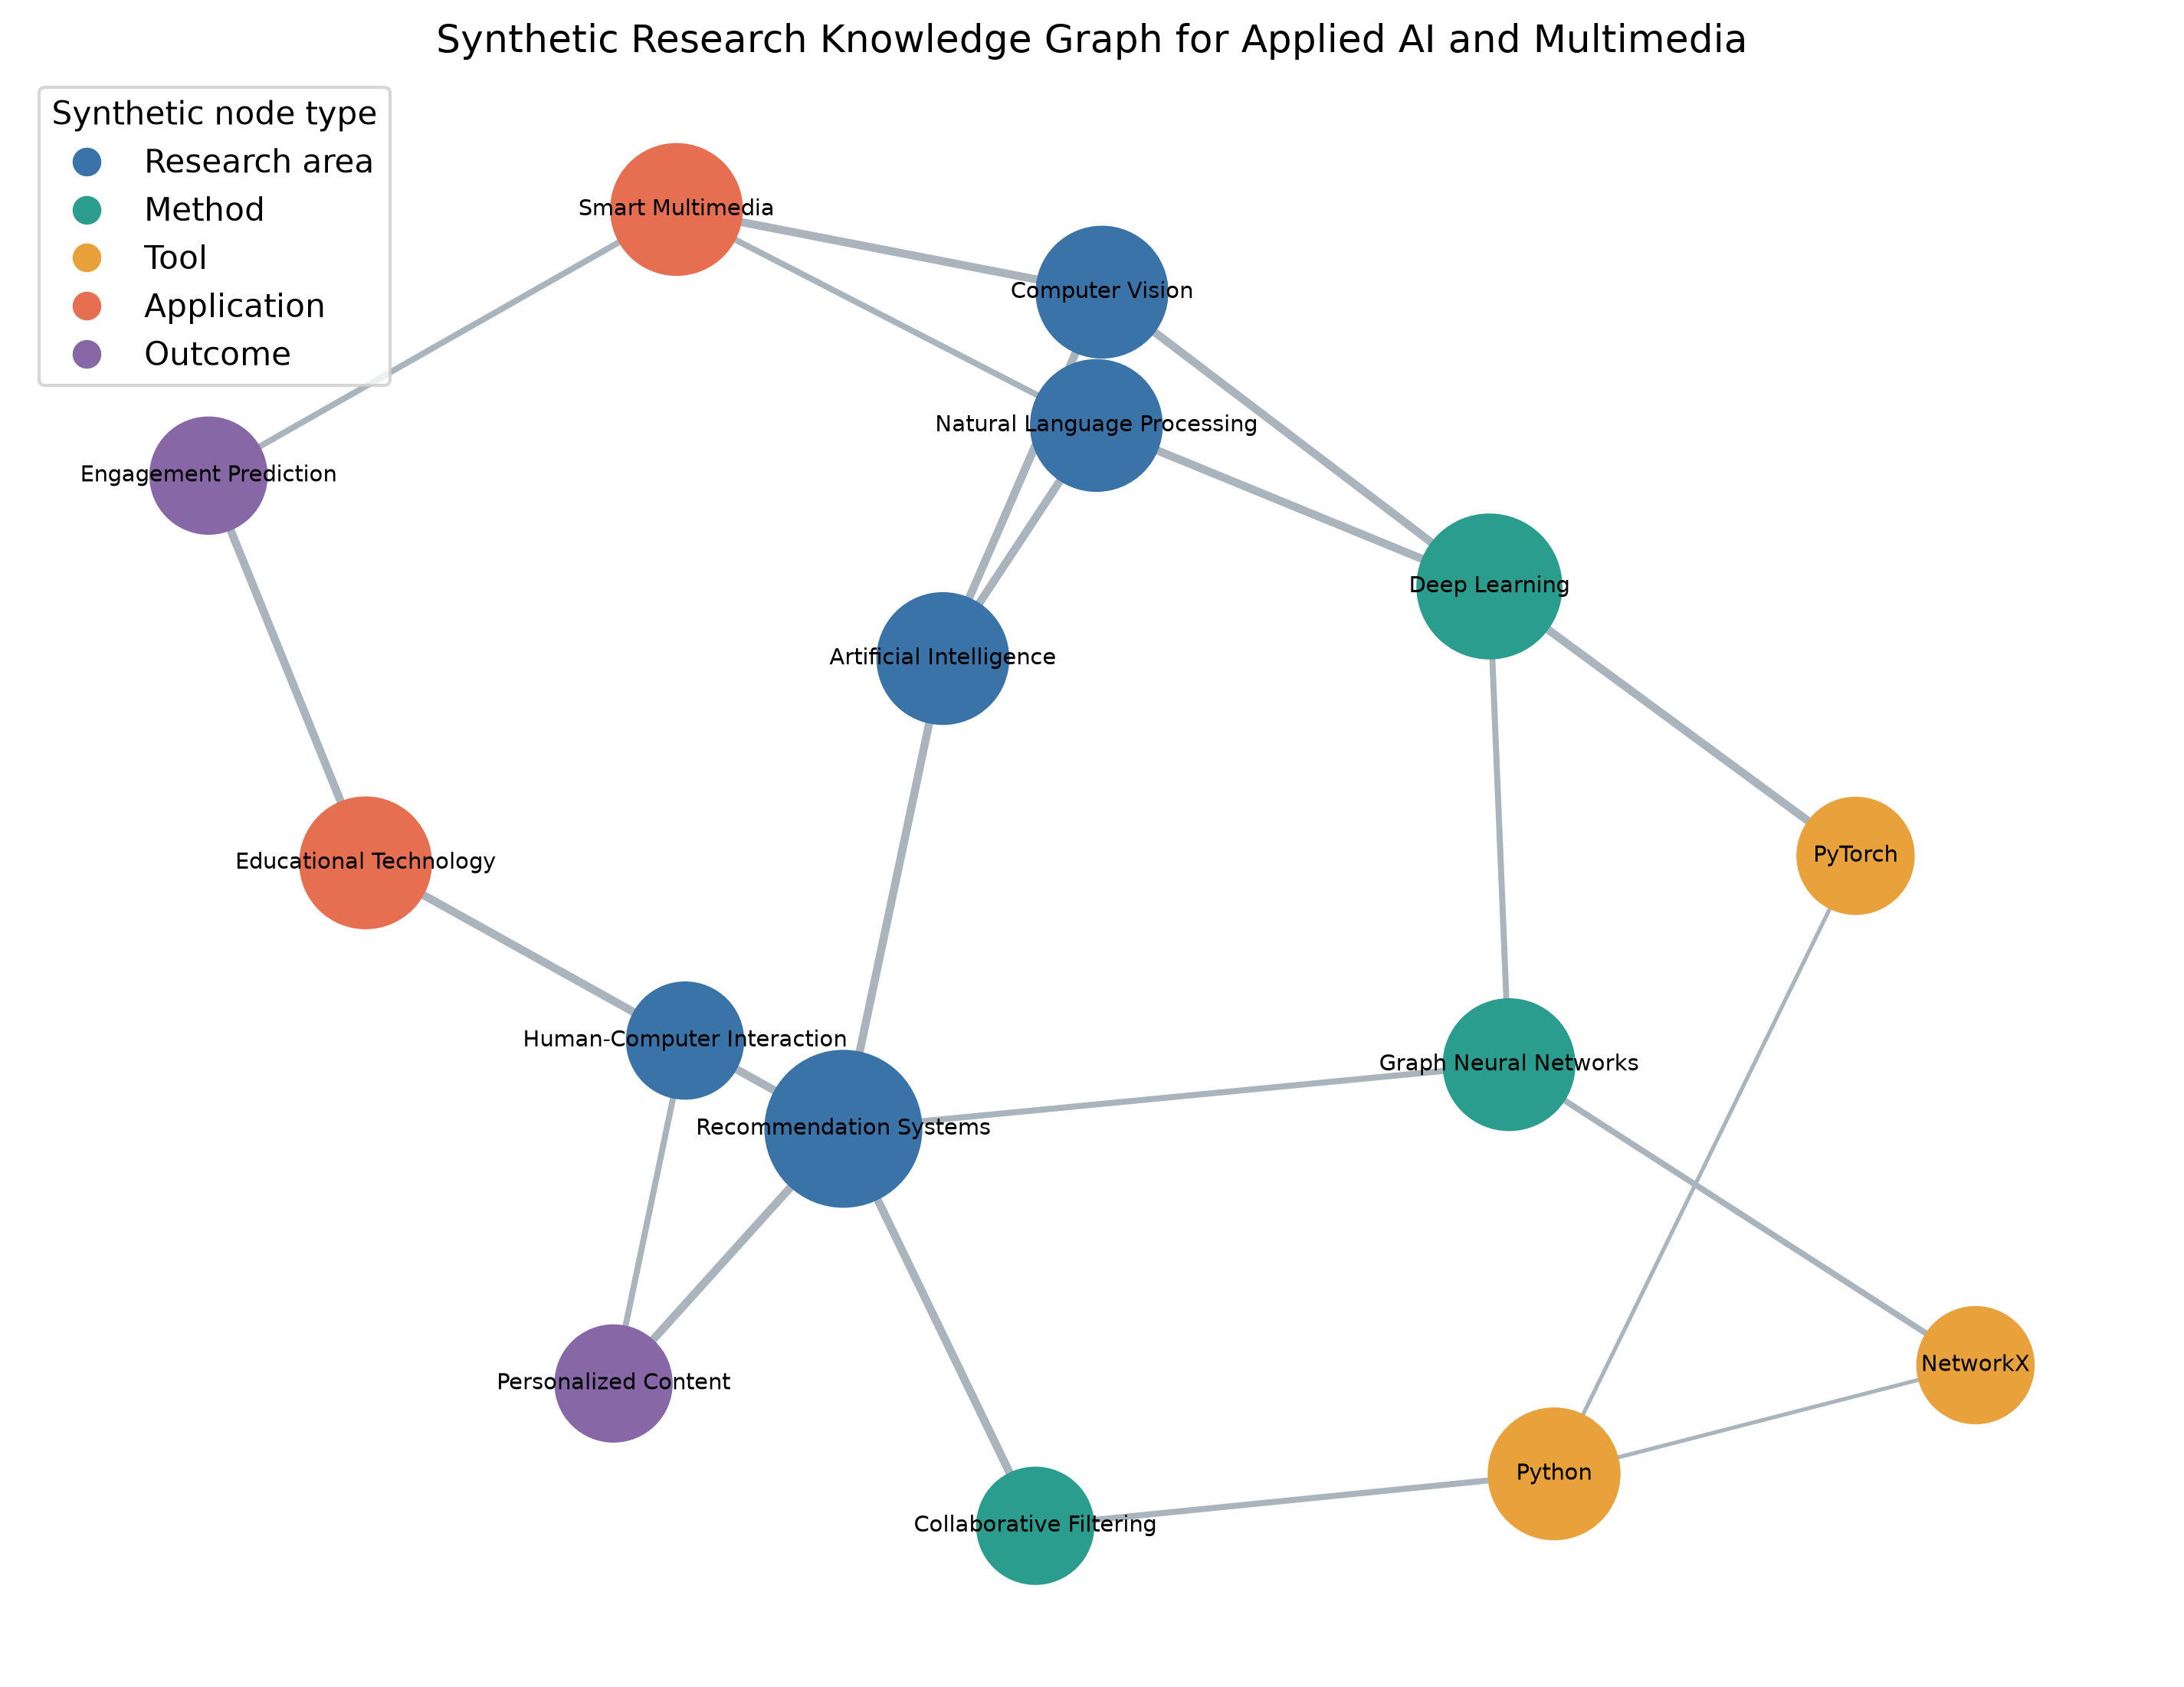

In [8]:
from src.network_analysis import domain_metrics
domain_table, domain_result = domain_metrics()
display(domain_table.head(10))
print('Top bridge:', domain_result['top_betweenness_node'], domain_result['top_betweenness_value'])
display(Image(filename=str(ROOT / 'visualizations' / 'static' / 'domain_graph.png')))

**Interpretation.** Recommendation Systems is the strongest bridge under inverse-strength weighted betweenness because it connects research themes, methods, and application outcomes.

**Limitation.** The graph is illustrative and is not evidence extracted from publications or a real research community.